# figure out how to do diff motif activity for spatial clusters -> then look at footprints for these

In [1]:
library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BiocFileCache

Loading required package: dbplyr

Loading required package: GenomeInfoDb

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, r

In [68]:
source("../backend/calc_multiome_scores/calc_global_motif_analysis.R")

In [ ]:
# spot_obj <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/spot_obj.rds")

In [ ]:
# spot_obj

An object of class Seurat 
165040 features across 1448 samples within 1 assay 
Active assay: peaks (165040 features, 0 variable features)
 2 layers present: counts, data

In [3]:
object <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/global_motif_analysis.rds")

In [ ]:
# object_reload <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/global_motif_analysis.rds")

In [4]:
M_path <- file.path("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/adata_map.X.csv")
M <- read.csv(M_path, row.names = 1)
spot_meta <- read.csv("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/adata_map.var.csv")


In [5]:
C <- GetAssayData(object, assay = "chromvar", layer = "data")
M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

C_spot <- C %*% M_sp

In [6]:
# print(head(colnames(C_spot)))
fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
# 1) fix spot IDs consistently
colnames(C_spot) <- fix_barcode(colnames(C_spot))
# print(head(colnames(C_spot)))

In [7]:
to_dgC <- function(x) {
  if (inherits(x, "dgCMatrix")) return(x)
  Matrix::Matrix(as.matrix(x), sparse = TRUE)
}

# Make sure C_spot is motifs x spots
C_spot_dgC <- to_dgC(C_spot)


In [8]:
rownames(spot_meta) <- spot_meta$X

In [9]:

# Create Seurat object from the MATRIX (not Assay)
spot_obj <- CreateSeuratObject(
  counts = C_spot_dgC,
  assay = "chromvar"
)

In [10]:
spot_obj[["chromvar"]]

Assay (v5) data with 720 features for 1448 cells
First 10 features:
 MA0069.1, MA0071.1, MA0074.1, MA0101.1, MA0107.1, MA0115.1, MA0119.1,
MA0130.1, MA0149.1, MA0155.1 
Layers:
 counts 

In [11]:

# THIS IS HOW IT CAN BE DONE:
spot_obj <- SetAssayData(
  object = spot_obj,
  assay  = "chromvar",
  layer  = "data",
  new.data = GetAssayData(spot_obj, assay = "chromvar", layer = "counts")
)

# Add metadata (now aligned)
spot_obj <- AddMetaData(spot_obj, spot_meta)


In [12]:
head(spot_obj@meta.data, n=1)

,orig.ident,nCount_chromvar,nFeature_chromvar,X,in_tissue,array_row,array_col,suspension_type,assay_ontology_term_id,Sample_ID,⋯,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,leiden,uniform_density,rna_count_based_density
,<fct>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
AAACACCAATAACTGC-1,SeuratProject,-38.07421,83,AAACACCAATAACTGC-1,1,59,19,na,EFO:0022857,CL-like1,⋯,triple-negative breast carcinoma,Homo sapiens,female,breast,unknown,adult stage,zuU(#yRj2=,0,0.0006906077,0.0006358049


In [13]:
colnames(spot_obj@meta.data)

[1] "orig.ident"                              
 [2] "nCount_chromvar"                         
 [3] "nFeature_chromvar"                       
 [4] "X"                                       
 [5] "in_tissue"                               
 [6] "array_row"                               
 [7] "array_col"                               
 [8] "suspension_type"                         
 [9] "assay_ontology_term_id"                  
[10] "Sample_ID"                               
[11] "organism_ontology_term_id"               
[12] "sex_ontology_term_id"                    
[13] "development_stage_ontology_term_id"      
[14] "self_reported_ethnicity_ontology_term_id"
[15] "disease_ontology_term_id"                
[16] "tissue_type"                             
[17] "tissue_ontology_term_id"                 
[18] "pathologist_annotation"                  
[19] "B.cells"                                 
[20] "CAFs"                                    
[21] "Cancer.Epithelial"                       
[22] "Endothelial"                             
[23] "Myeloid"                                 
[24] "Normal.Epithelial"                       
[25] "PVL"                                     
[26] "T.cells"                                 
[27] "stereoscope_annotation"                  
[28] "cell_type_ontology_term_id"              
[29] "is_primary_data"                         
[30] "treatment"                               
[31] "donor_id"                                
[32] "cell_type"                               
[33] "assay"                                   
[34] "disease"                                 
[35] "organism"                                
[36] "sex"                                     
[37] "tissue"                                  
[38] "self_reported_ethnicity"                 
[39] "development_stage"                       
[40] "observation_joinid"                      
[41] "leiden"                                  
[42] "uniform_density"                         
[43] "rna_count_based_density"

In [14]:
unique(spot_obj@meta.data["development_stage"])

,development_stage
,<chr>
AAACACCAATAACTGC-1,adult stage


In [15]:
Idents(spot_obj) <- "cell_type"

In [16]:
diff_motif_activity_for_ident <- function(
    object,
    ident1,
    ident2 = NULL,
    save_in_misc = TRUE,
    chromvar_assay = "chromvar",
    only_pos = TRUE,
    logfc.threshold = 0.05

    ){
    differential.activity <- FindMarkers(
        object = object,
        ident.1 = ident1,
        ident.2 = ident2,
        assay = chromvar_assay,
        only.pos = only_pos,
        mean.fxn = rowMeans,
        fc.name = "avg_diff",
        logfc.threshold = logfc.threshold
        )
    if (save_in_misc){
        if (is.null(object@misc$diff_motif_activity)){
            object@misc$diff_motif_activity <- list()
        }
        if (is.null(ident2)){
            ident2 <- "rest"
        }
        # save under ident1_vs_ident2
        object@misc$diff_motif_activity[[paste0(as.character(ident1), "_vs_", as.character(ident2))]] <- differential.activity
        return(object)
    }
    return(differential.activity)
}

In [17]:
unique(spot_obj@meta.data["cell_type"])$"cell_type"

[1] "B cell"            "myeloid cell"      "malignant cell"   
[4] "fibroblast"        "endothelial cell"  "T cell"           
[7] "epithelial cell"   "perivascular cell"

In [18]:
test <- spot_obj
for (cell_type in unique(spot_obj@meta.data["cell_type"])$"cell_type") {
    n1 <- sum(Idents(test) == cell_type)

    if (n1 < 3) {
        message("Skipping ", cell_type, " (n=", n1, " < 3)")
        next
    }
    test<-diff_motif_activity_for_ident(
        object=test,
        ident1=cell_type,
        ident2 = NULL,
        save_in_misc = TRUE,
        chromvar_assay = "chromvar",
        only_pos = FALSE,
        logfc.threshold = 0.1
    )
}


Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Skipping T cell (n=2 < 3)

Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”


In [19]:
test@misc

$diff_motif_activity
$diff_motif_activity$`B cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`myeloid cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`malignant cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$fibroblast_vs_rest
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`endothelial cell_vs_rest`
                p_val  avg_diff pct.1 pct.2 p_val_adj
MA0144.3 0.0007077597 0.1080402 0.556 0.268  0.509587

$diff_motif_activity$`epithelial cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`perivascular cell_vs_rest`
               p_val  avg_diff pct.1 pct.2 p_val_adj
MA2335.1 0.001802081 0.1035888  1.00 0.423         1
MA0665.1 0.002763167 0.1266437  1.00 0.341         1
MA0691.1 0.002964718 0.1005442  1.00 0.321         1
MA0090.4 0.016874474 0.1219190  0.75 0.245         1
MA1979.2 0.021880196 0.1065190  0.75 0.349         1

## footprint for these motifs

In [62]:
# use dissociated object for footprinting
frag_obj <- CreateFragmentObject(
    #TODO: use provided fragment path, currently upload not working
    #path  = args$fragments_tsv_gz,
    path = "../backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz",
    cells = colnames(object)   # restrict to cells in this object
)

Computing hash



In [63]:
object[["peaks"]]@fragments <- list(frag_obj)

In [66]:
str(Fragments(object))

List of 1
 $ :Formal class 'Fragment' [package "Signac"] with 3 slots
  .. ..@ path : chr "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
  .. ..@ hash : chr [1:2] "2457edd8ea322b4366c96ca5b4d6506d" "abb1b86c63f85c2de767081039af0e33"
  .. ..@ cells: Named chr [1:297] "AAACGTACATCATGTG-1" "AAAGCTTGTGACCTGG-1" "AAAGGAGCAAGGGTTG-1" "AAAGGCTCAACGTGCT-1" ...
  .. .. ..- attr(*, "names")= chr [1:297] "AAACGTACATCATGTG-1" "AAAGCTTGTGACCTGG-1" "AAAGGAGCAAGGGTTG-1" "AAAGGCTCAACGTGCT-1" ...


In [ ]:

# object[["peaks"]]@fragments <- list(frag_obj)
# print("computing Tn5 insertion bias")
# object <- compute_Tn5_insertion_Bias(object, genome = BSgenome.Hsapiens.UCSC.hg38, assay = "peaks")

[1] "computing Tn5 insertion bias"


Extracting reads in requested region



In [22]:
str(Fragments(object)[[1]])

Formal class 'Fragment' [package "Signac"] with 3 slots
  ..@ path : chr "/workspaces/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
  ..@ hash : chr [1:2] "2457edd8ea322b4366c96ca5b4d6506d" "abb1b86c63f85c2de767081039af0e33"
  ..@ cells: Named chr [1:297] "AAACGTACATCATGTG-1" "AAAGCTTGTGACCTGG-1" "AAAGGAGCAAGGGTTG-1" "AAAGGCTCAACGTGCT-1" ...
  .. ..- attr(*, "names")= chr [1:297] "AAACGTACATCATGTG-1" "AAAGCTTGTGACCTGG-1" "AAAGGAGCAAGGGTTG-1" "AAAGGCTCAACGTGCT-1" ...
  .. ..- attr(*, ".match.hash")=Class 'match.hash' <externalptr> 


In [47]:
spatialObj_add_fragments_dissociated2spatial <- function(
    object_dissociated,
    M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj, 
    assay = "peaks",
    slot = "counts"
){
    C <- GetAssayData(object_dissociated, assay = assay, slot = slot)
    # force to 2D numeric (and to sparse for speed)
    M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

    C_spot <- C %*% M_sp
    colnames(C_spot) <- fix_barcode(colnames(C_spot))

    ranges <- granges(object_dissociated[[assay]])  # peak GRanges from your multiome object

    chrom_spot <- CreateChromatinAssay(
        counts = C_spot,
        ranges = ranges,
        genome = genome(object_dissociated[[assay]]), # or "hg38"
        motifs = Motifs(object_dissociated[[assay]]),
        annotation = Annotation(object_dissociated[[assay]]),
        #fragments = Fragments(object_dissociated[[assay]])
        # Fragments is per cell, so we cannot transfer it here/ would have to aggregate with M
    )

    # spot_obj <- CreateSeuratObject(counts = chrom_spot, assay = assay)
    # Add new assay to existing spot_obj
    spot_obj[[assay]] <- chrom_spot

    DefaultAssay(spot_obj) <- assay

    spot_obj <- AddMetaData(spot_obj, spot_obj@meta.data)
    fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
    return(spot_obj)

}

In [48]:


test2 <- spatialObj_add_fragments_dissociated2spatial(
    object_dissociated= object,
    M=M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj=test, 
    assay = "peaks",
    slot = "counts"
)    

In [49]:
test2[["peaks"]]

ChromatinAssay data with 165040 features for 1448 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: TRUE 
Fragment files: 0 

In [ ]:
plot_footprint_for_motif <- function(
  motif_name,
  M=NULL, 
  M_path=NULL, # eg adata_map.X.csv
  spot_obj=NULL,
  spot_obj_path=NULL,
  object_dissociated = NULL,
  object_dissociated_path = NULL,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) {

  # Safety checks for overwrite behavior
  if (!overwrite) {
    if (file.exists(object_dissociated_out_path)) {
      stop("Refusing to overwrite existing file: ", object_dissociated_out_path)
    }
    if (file.exists(spot_obj_out_path)) {
      stop("Refusing to overwrite existing file: ", spot_obj_out_path)
    }
  }
  if (is.null(object_dissociated)) {
    if (is.null(object_dissociated_path)) {
      stop("Either object_dissociated or object_dissociated_path must be provided.")
    }
    object_dissociated <- readRDS(object_dissociated_path)
  }
  if (is.null(M)) {
    if (is.null(M_path)) {
      stop("Either M or M_path must be provided.")
    }
    M <- read.csv(M_path, row.names = 1, check.names = FALSE)
  }
  if (is.null(spot_obj)) {
    if (is.null(spot_obj_path)) {
      stop("Either spot_obj or spot_obj_path must be provided.")
    }
    spot_obj <- readRDS(spot_obj_path)
  }

  key <- sprintf("footprint_%s", paste(motif_name))

  # Compute footprint in dissociated object
  object_dissociated <- Signac::Footprint(
    object = object_dissociated,
    motif.name = motif_name,
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE,
    key = key
  )

  # Project dissociated footprint to spots
  fp_spots_all <- footprints_dissociated2spatial(
    object_dissociated = object_dissociated,
    footprint_key = key,
    M = M,
    assay = assay
  )

  rownames(fp_spots_all) <- fix_barcode(rownames(fp_spots_all))
  # Store in spot object
  spot_obj[[assay]]@positionEnrichment[[key]] <- fp_spots_all
  Seurat::Idents(spot_obj) <- clustering_var

  # Persist updated objects to disk
  saveRDS(object_dissociated, file = object_dissociated_out_path)
  saveRDS(spot_obj, file = spot_obj_out_path)

  # Plot
  p <- Signac::PlotFootprint(
    object = spot_obj,
    features = key,
    group.by = clustering_var,
    show.expected = TRUE,
    normalization = "subtract"
  )
  if (!is.null(plot_out_path)) {
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }else{
    plot_out_path <- file.path(dirname(spot_obj_out_path),paste0("footprint_", motif_name, ".pdf"))
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }

  return(p)
}

In [53]:
test2@misc

$diff_motif_activity
$diff_motif_activity$`B cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`myeloid cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`malignant cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$fibroblast_vs_rest
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`endothelial cell_vs_rest`
                p_val  avg_diff pct.1 pct.2 p_val_adj
MA0144.3 0.0007077597 0.1080402 0.556 0.268  0.509587

$diff_motif_activity$`epithelial cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`perivascular cell_vs_rest`
               p_val  avg_diff pct.1 pct.2 p_val_adj
MA2335.1 0.001802081 0.1035888  1.00 0.423         1
MA0665.1 0.002763167 0.1266437  1.00 0.341         1
MA0691.1 0.002964718 0.1005442  1.00 0.321         1
MA0090.4 0.016874474 0.1219190  0.75 0.245         1
MA1979.2 0.021880196 0.1065190  0.75 0.349         1

In [71]:
start <- Sys.time()

p <- plot_footprint_for_motif(
  motif_name = "MA0144.3",
  M=M, # eg adata_map.X.csv
  spot_obj=test2,
  object_dissociated = object,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) 
end <- Sys.time()
print(end - start)

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



ERROR: Error in .subscript.2ary(x, i, , drop = drop): subscript out of bounds


In [72]:
spot_obj_out <-readRDS("spot_obj_out.rds")

In [80]:

rownames(spot_obj_out[["peaks"]]@positionEnrichment$footprint_MA0144.3) <- fix_barcode(rownames(spot_obj_out[["peaks"]]@positionEnrichment$footprint_MA0144.3))

In [82]:
key <- "footprint_MA0144.3"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "cell_type",
  show.expected = TRUE,
  normalization = "subtract"
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”


Warning message:
“Removed 4072 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


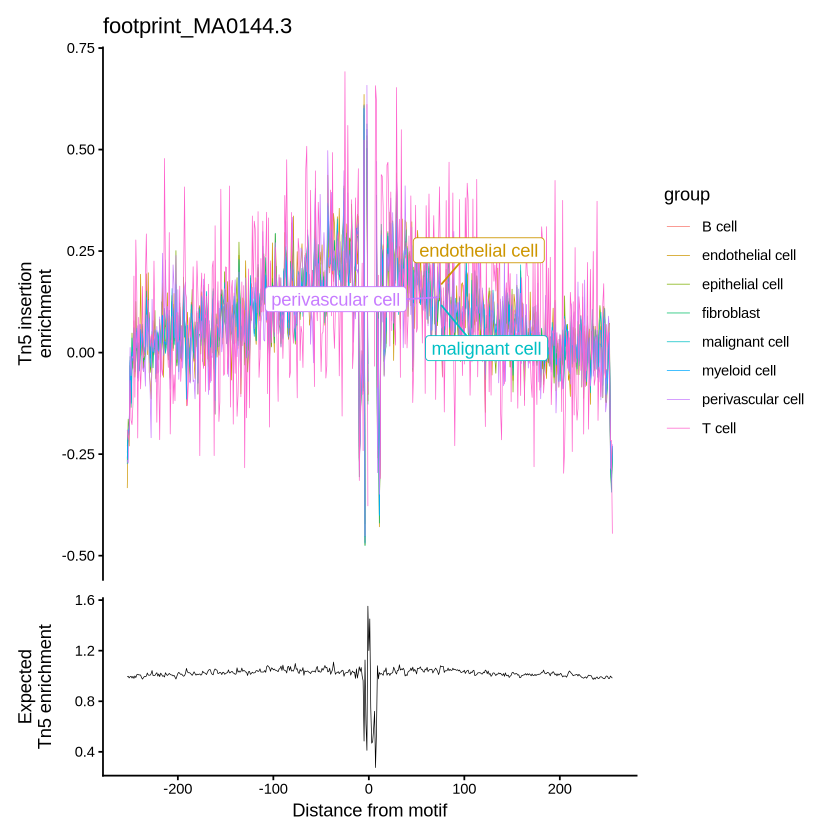

In [84]:
p

In [85]:
key <- "footprint_MA0144.3"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "leiden",
  show.expected = TRUE,
  normalization = "subtract"
)

Warning message:
“Removed 5090 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


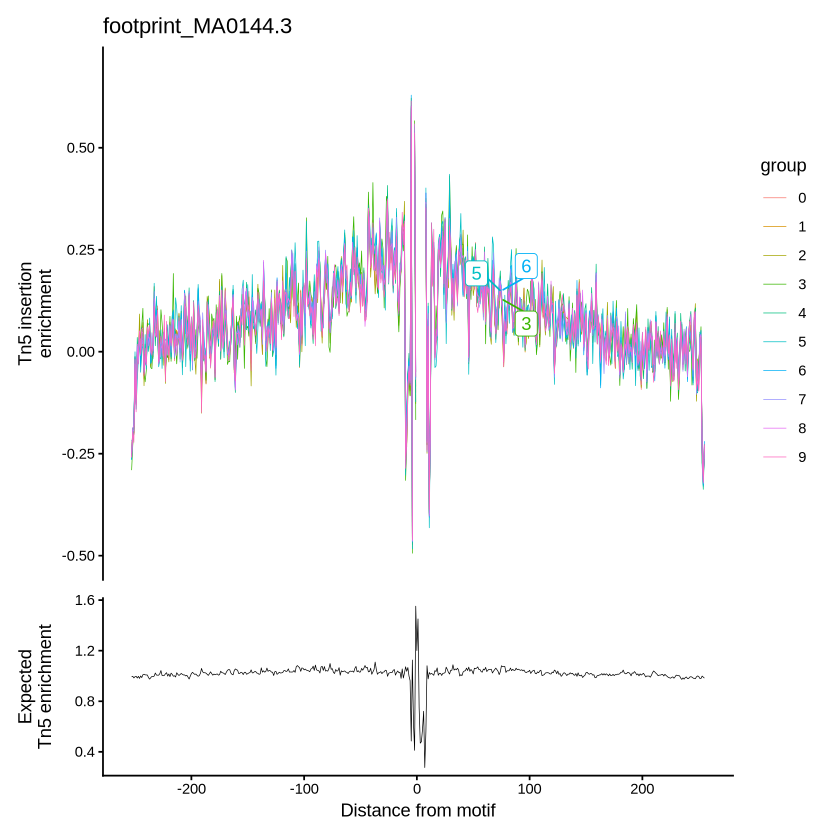

In [86]:
p

In [93]:
str(spot_obj_out[["peaks"]],max.level = 2)

Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ ranges            :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ motifs            :Formal class 'Motif' [package "Signac"] with 5 slots
  ..@ fragments         : list()
  ..@ seqinfo           : NULL
  ..@ annotation        :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ bias              : NULL
  ..@ positionEnrichment:List of 1
  ..@ links             :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ counts            :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ data              :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ scale.data        : num[0 , 0 ] 
  ..@ assay.orig        : NULL
  ..@ var.features      : logi(0) 
  ..@ meta.features     :'data.frame':	165040 obs. of  0 variables
  ..@ misc              : Named list()
  ..@ key               : chr "peaks_"


In [120]:
spot_obj_out@meta.data$is_Endothelial <-
  spot_obj_out@meta.data$cell_type == "endothelial cell"

In [121]:
table(spot_obj_out@meta.data$is_Endothelial, useNA = "ifany")


FALSE  TRUE 
 1439     9 

In [119]:
table(spot_obj_out@meta.data$cell_type)


           B cell  endothelial cell   epithelial cell        fibroblast 
              646                 9                14               237 
   malignant cell      myeloid cell perivascular cell            T cell 
               81               455                 4                 2 

Warning message:
“Removed 1018 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


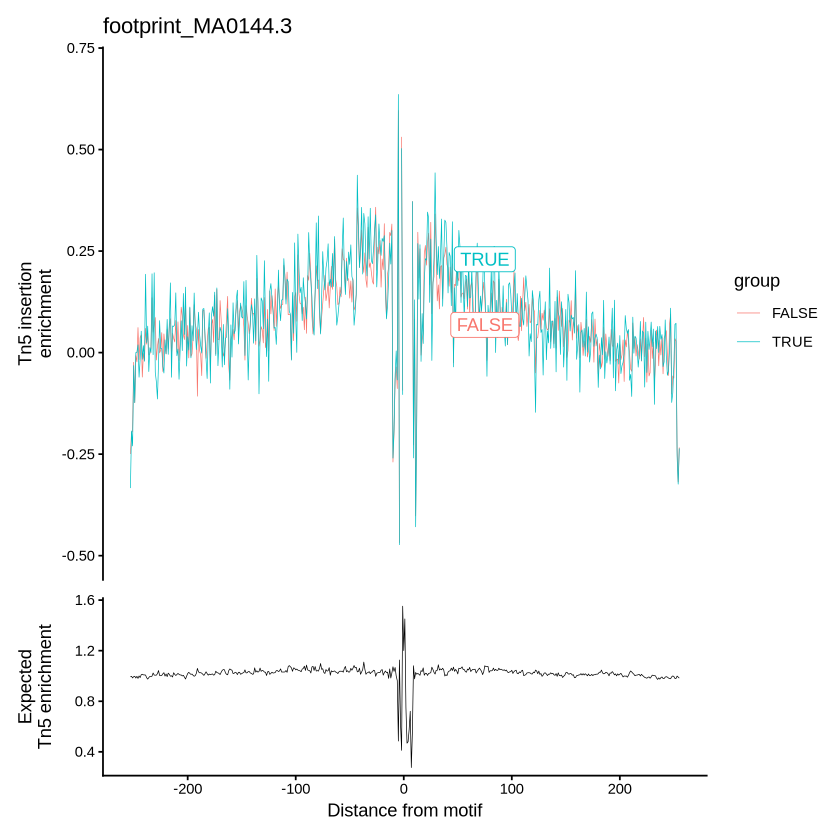

In [122]:
key <- "footprint_MA0144.3"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "is_Endothelial",
  show.expected = TRUE,
  normalization = "subtract"
)
p